In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_excel('ENB2012_data.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [4]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [5]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


In [6]:
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

Duplicates: 0
(768, 10)


count    768.000000
mean      22.307195
std       10.090204
min        6.010000
25%       12.992500
50%       18.950000
75%       31.667500
max       43.100000
Name: Y1, dtype: float64


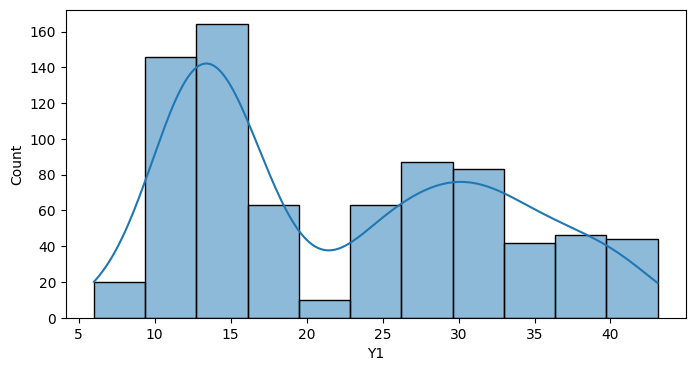

In [7]:
target = 'Y1'
print(df[target].describe())

plt.figure(figsize=(8,4))
sns.histplot(df[target], kde=True)
plt.show()

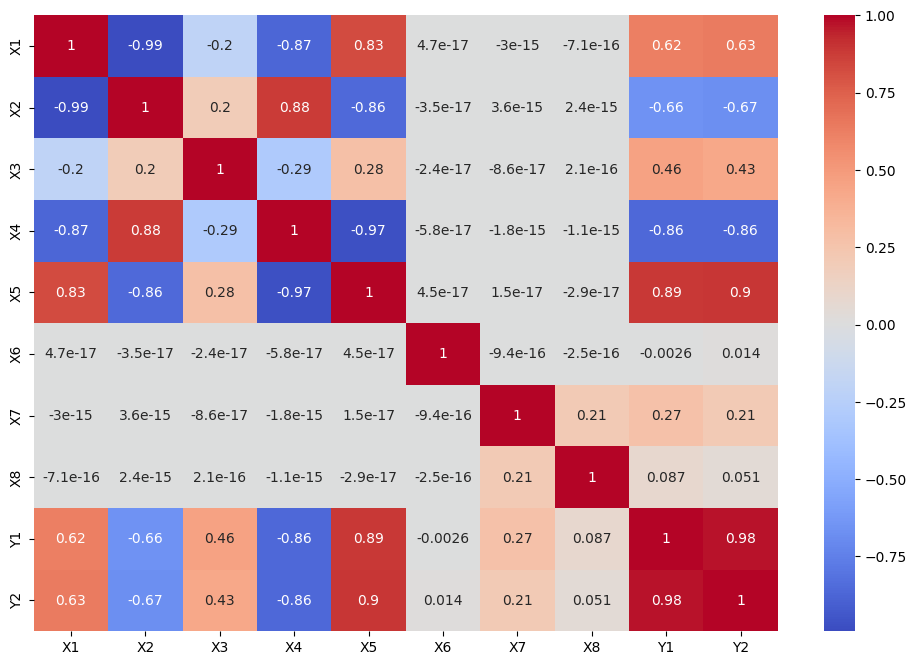

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm',annot=True)
plt.show()

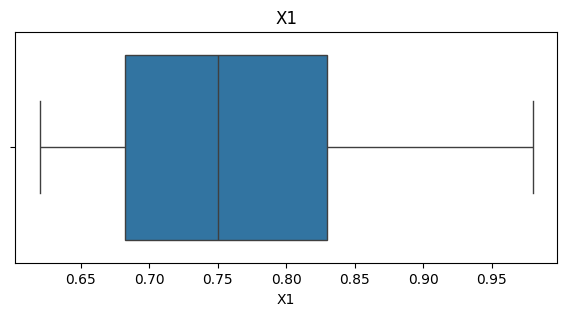

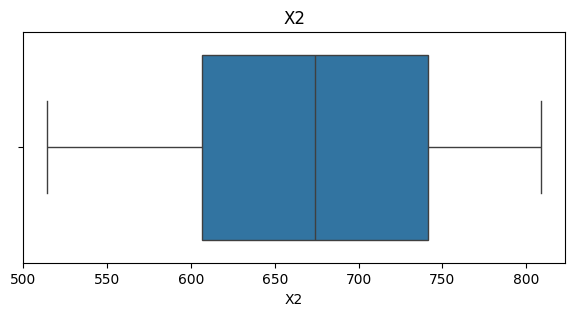

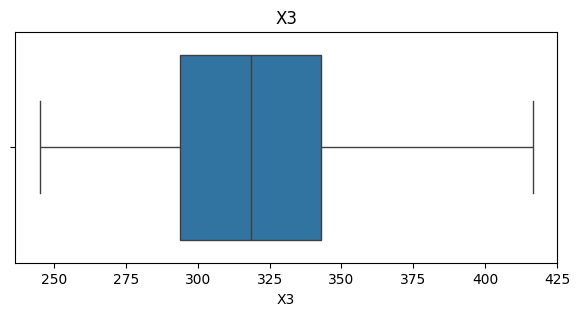

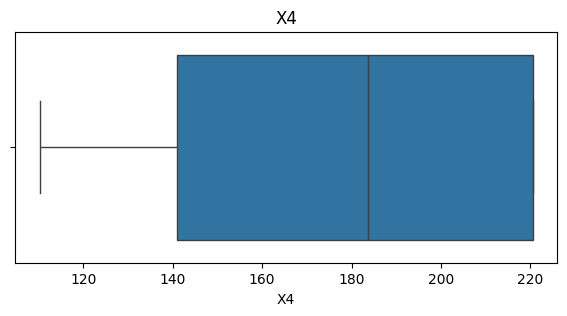

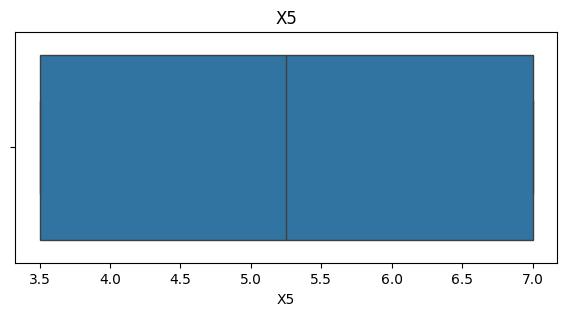

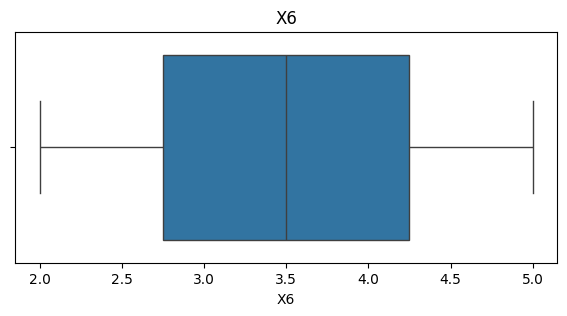

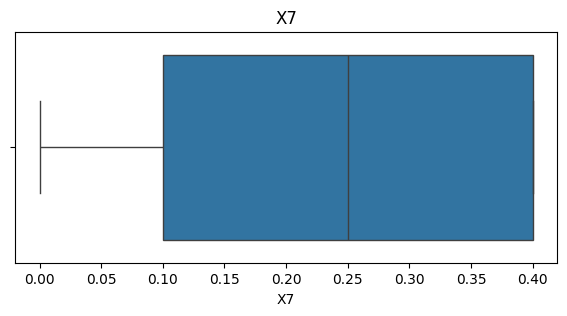

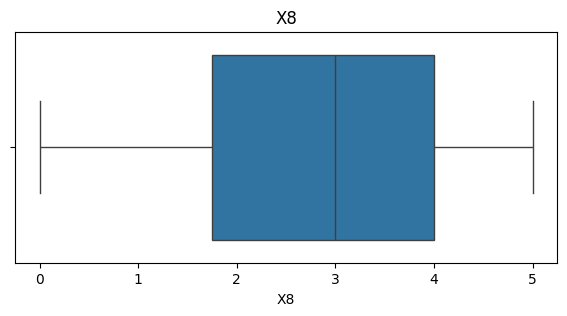

In [9]:
for col in df.columns[:-2]:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [10]:
X = df.drop(columns=['Y1','Y2'])
y = df['Y1']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print('MAE:', mean_absolute_error(y_test,pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,pred)))
print('R2:', r2_score(y_test,pred))

MAE: 1.4678311688311687
RMSE: 2.307891346561286
R2: 0.9488991715318557


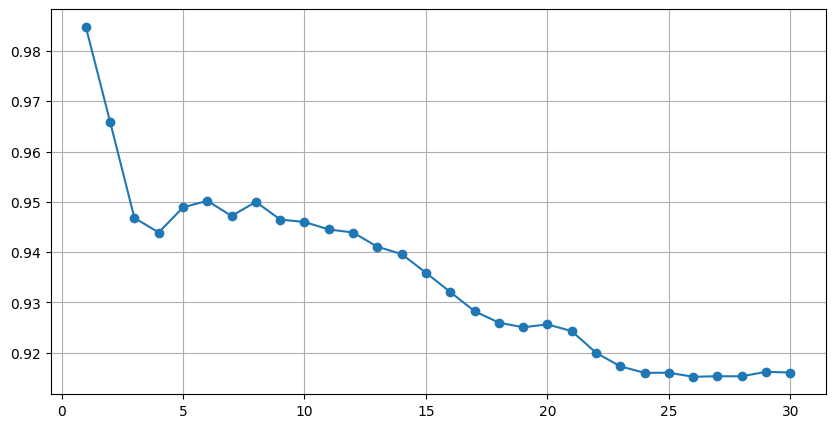

Best K: 1


In [14]:
r2_scores = []

for k in range(1,31):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train,y_train)
    p = model.predict(X_test)
    r2_scores.append(r2_score(y_test,p))

plt.figure(figsize=(10,5))
plt.plot(range(1,31),r2_scores,marker='o')
plt.grid()
plt.show()

best_k = np.argmax(r2_scores)+1
print('Best K:',best_k)

In [15]:
param_grid = {
    'n_neighbors':[3,5,7,9,11,13,15],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan','minkowski']
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
0.9804581564852499


In [16]:
final_model = grid.best_estimator_
final_model.fit(X_train,y_train)

final_pred = final_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test,final_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,final_pred)))
print('R2:', r2_score(y_test,final_pred))

MAE: 0.7976797967751184
RMSE: 1.1580877035053596
R2: 0.9871329163524953


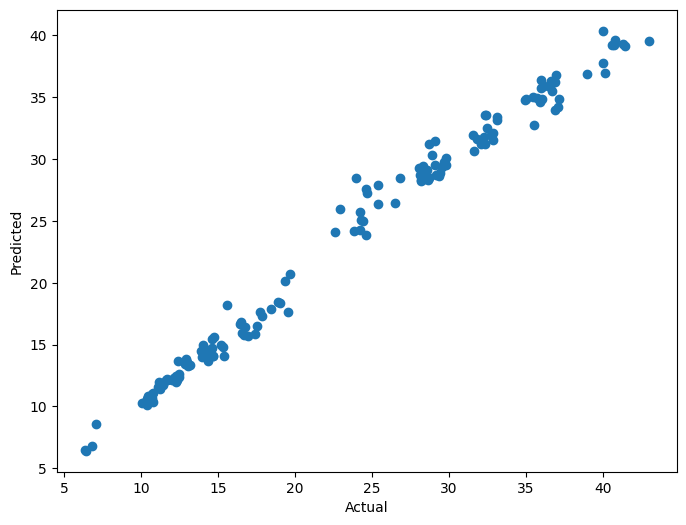

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [18]:
joblib.dump(final_model,'energy_efficiency_knn_regressor.pkl')
print('Model Saved')

Model Saved
